# Data Mining II (Spring Semester 2025-2026)
---
## Project: Reach for Change | Predicting Donor Response to Optimize Outreach for Social Good
**Group:** TBD  
**Authors:**
* João Galamba - 20250131
* Tamara Arakelyan - 20250290
* Thiago Bellas - 20231131

---

## <b><span style='color:#e61227'></span>Predicting Donor Response to Optimize Outreach for Social Good</b>

# <b><span style='color:#e61227'></span> Introduction<b>

## <b><span style='color:#e61227'></span> Purpose<b>

The main goal of this project is to predict whether a donor will respond positively to a future campaign, while keeping the full modeling workflow transparent and reproducible. The metodology follows a strict separation between **training**, **validation**, and **internal test** data. This design was chosen to avoid optimistic model selection and to make the final performance estimate more credible.

The independent Kaggle test file is only used after model development is complete, exactly as expected in a realistic deployment setting.

## <b><span style='color:#e61227'></span> What this notebook aims to demonstrate<b>

1. A clear and justified preprocessing strategy.
2. A concise but meaningful exploratory analysis **focused on decision-making**.
3. A classification pipeline based on methods covered in class.
4. A model assessment strategy aligned with the project guidelines and the Kaggle F1 objective.
5. A transparent optimization procedure that includes both hyperparameter tuning and probability-threshold selection.
6. An open-ended analytical section that goes beyond simply fitting a predictive pipeline.


## <b><span style='color:#e61227'></span> Methodological summary<b>

- **Input data**: `donors_train.csv` for model development and `donors_test.csv` for final prediction.
- **Target**: `TARGET_B`.
- **Identifier excluded from modeling**: `CONTROL_NUMBER`.
- **Assessment design**: internal **train / validation / test** split.
- **Selection metric**: **F1 score**, because the competition is ranked with binary F1 and the class distribution is imbalanced.
- **Candidate models**: Logistic Regression, Decision Tree, Random Forest, and Extra Trees.
- **Final deployment step**: refit the chosen configuration on train + validation, freeze the validation-selected threshold, and produce Kaggle predictions for the unseen test file.


# <b><span style='color:#e61227'></span> Project Development<b>

### <b><span style='color:#e61227'></span> Reading guide<b>

Each section starts with a short statement of purpose, followed by code and then interpretation.

The notebook is intentionally written so that a first-time reader can understand not only **what** is done, but also **why** each decision was made.

---

## <b><span style='color:#e61227'></span> 1. Imports and notebook global configuration<b>

This section gathers all libraries, metrics, and global constants used throughout the notebook.

### <b><span style='color:#e61227'></span> Why centralize imports?<b>

Centralizing imports improves readability and reproducibility. A reviewer should be able to inspect one cell and immediately understand:

- which packages are required,
- which modeling families are being considered,
- which evaluation metrics drive the project,
- and which random seed ensures reproducibility.

### <b><span style='color:#e61227'></span> Design principles followed here<b>

- Only **vanilla scikit-learn** models and utilities are used, which keeps the notebook aligned with the project restrictions.
- The configuration uses a fixed `RANDOM_STATE` so that splits and stochastic algorithms can be replicated.
- Performance metrics are imported explicitly instead of being called indirectly, making the evaluation protocol transparent.
- Plot defaults are configured once to keep visual output consistent and uncluttered.


In [0]:
# Silence non-critical warnings to keep notebook output readable during presentation.
import warnings
warnings.filterwarnings('ignore')

# Core scientific Python stack.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Scikit-learn utilities for mixed-type preprocessing and reproducible pipelines.
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate

# Metrics selected to support threshold-dependent and threshold-independent assessment.
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Model inspection utility used in the open-ended section.
from sklearn.inspection import permutation_importance

# Candidate algorithms explored in the benchmark.
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier

# Global constants used throughout the notebook for reproducibility and readability.
RANDOM_STATE = 42
TARGET = 'TARGET_B'
ID_COL = 'CONTROL_NUMBER'

# Plot configuration chosen for consistent visual output.
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['axes.grid'] = True



## <b><span style='color:#e61227'></span> 2. Loading the real project data<b>

The first operational step is to read the original CSV files supplied for the project.

`donors_train.csv`

`donors_test.csv`

### <b><span style='color:#e61227'></span> Why start from the raw files?<b>

For reproducibility, it is important that the notebook begins from the real data sources rather than from an already processed object. This makes the workflow auditable from the first step and helps verify that:

- the notebook can run end to end,
- the same logic is applied every time,
- and no hidden preprocessing is occurring outside the notebook.

At this stage we only inspect the dataset dimensions and preview a few rows. This is enough to confirm that the files were loaded correctly, without mixing exploration and preprocessing too early.


In [0]:
# Define the file paths for the labeled development data and the unlabeled Kaggle test data.
train_path = 'donors_train.csv'
test_path = 'donors_test.csv'

# Load the original CSV files exactly as provided for the project.
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

# Quick structural validation: dimensions should be consistent with expectations.
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

# Display the first rows to verify that variables were read correctly.
train_df.head()


Train shape: (13560, 41)
Test shape : (5812, 40)


,CONTROL_NUMBER,CARD_PROM_12,CHILDREN,DONOR_AGE,DONOR_GENDER,FILE_CARD_GIFT,FREQUENCY_STATUS_97NK,HOME_OWNER,INCOME_GROUP,LAST_GIFT_AMT,LIFETIME_CARD_PROM,LIFETIME_GIFT_AMOUNT,LIFETIME_GIFT_COUNT,LIFETIME_MAX_GIFT_AMT,LIFETIME_MIN_GIFT_AMT,LIFETIME_PROM,MEDIAN_HOME_VALUE,MEDIAN_HOUSEHOLD_INCOME,MONTHS_SINCE_FIRST_GIFT,MONTHS_SINCE_LAST_GIFT,MONTHS_SINCE_LAST_PROM_RESP,NUMBER_PROM_12,PCT_ATTRIBUTE1,PCT_ATTRIBUTE2,PCT_ATTRIBUTE3,PCT_ATTRIBUTE4,PCT_OWNER_OCCUPIED,PEP_STAR,PER_CAPITA_INCOME,RECENCY_STATUS_96NK,RECENT_AVG_CARD_GIFT_AMT,RECENT_AVG_GIFT_AMT,RECENT_CARD_RESPONSE_COUNT,RECENT_CARD_RESPONSE_PROP,RECENT_RESPONSE_COUNT,RECENT_RESPONSE_PROP,RECENT_STAR_STATUS,SES,URBANICITY,WEALTH_RATING,TARGET_B
0,61745,4.0,3.0,33.0,M,0.0,1.0,H,5.0,20.0,9.0,35.0,2.0,20.0,15.0,21.0,566.0,315.0,182.037132,18.0,18.0,10.0,0.0,52.0,17.0,25.0,92.0,0.0,12827.0,A,0.00,17.50,NaN,0.000,2.0,0.154,0.0,2,T,NaN,1
1,112703,3.0,2.0,NaN,F,1.0,1.0,U,NaN,15.0,6.0,15.0,1.0,15.0,15.0,15.0,318.0,148.0,24.000000,24.0,24.0,7.0,0.0,31.0,31.0,39.0,73.0,0.0,7787.0,N,15.00,15.00,1.0,0.250,1.0,0.100,0.0,3,R,NaN,1
2,166437,4.0,2.0,NaN,F,7.0,3.0,H,4.0,10.0,17.0,79.0,11.0,12.0,5.0,40.0,1669.0,373.0,129.000000,15.0,15.0,8.0,0.0,26.0,39.0,38.0,84.0,1.0,13965.0,S,0.00,10.67,0.0,0.000,3.0,0.231,1.0,1,U,NaN,0
3,170621,4.0,NaN,61.0,M,13.0,1.0,H,6.0,11.0,28.0,80.0,17.0,11.0,3.0,75.0,1464.0,488.0,130.000000,16.0,16.0,13.0,0.0,48.0,30.0,44.0,84.0,1.0,24123.0,A,10.00,10.00,2.0,0.286,2.0,0.111,0.0,1,U,NaN,0
4,44428,6.0,0.0,75.0,M,3.0,4.0,H,3.0,7.0,9.0,27.0,5.0,7.0,5.0,22.0,936.0,249.0,24.000000,17.0,17.0,13.0,0.0,52.0,NaN,66.0,90.0,1.0,15008.0,N,5.67,5.40,3.0,0.600,5.0,0.500,0.0,2,C,NaN,0


# Stats (Need To be write)

Discrepances:
Children
Donor_Age
FILE_CARD_GIFT


In [0]:
train_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CONTROL_NUMBER,13560.0,NaN,NaN,NaN,96433.007743,55926.026991,5.0,47975.25,97023.0,145252.75,191775.0
CARD_PROM_12,13297.0,NaN,NaN,NaN,5.379945,1.31719,1.0,5.0,6.0,6.0,17.0
CHILDREN,13298.0,NaN,NaN,NaN,1.996802,1.466203,-2.299824,1.0,2.0,3.0,6.220526
DONOR_AGE,10006.0,NaN,NaN,NaN,58.814086,17.568008,0.0,46.0,60.0,73.0,108.94645
DONOR_GENDER,13288,3,F,7230,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FILE_CARD_GIFT,13300.0,NaN,NaN,NaN,5.242995,4.833704,-10.09857,2.0,4.0,8.0,32.0
FREQUENCY_STATUS_97NK,13278.0,NaN,NaN,NaN,1.993986,1.147577,-1.363824,1.0,2.0,3.0,5.279946
HOME_OWNER,13274,2,H,7233,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INCOME_GROUP,10271.0,NaN,NaN,NaN,3.923575,1.957765,-1.737977,2.0,4.0,5.0,9.50328
LAST_GIFT_AMT,13299.0,NaN,NaN,NaN,16.639062,12.952247,-21.8336,10.0,15.0,20.0,450.0


## <b><span style='color:#e61227'></span> 3. Initial cleaning and leakage-aware split design<b>

This section is one of the most critical parts of the project because it defines the methodological integrity of the entire predictive pipeline. In supervised learning, strong results are only meaningful if the data preparation and evaluation framework prevent information from leaking from future stages of the workflow into earlier ones. For that reason, the purpose of this step is not only to clean the raw data, but also to establish a split design that preserves a strict separation between model development and model evaluation.

### <b><span style='color:#e61227'></span> Objective of this step<b>

At this stage, the dataset is prepared for modeling while ensuring that each analytical decision is made under a leakage-aware framework. In practical terms, this means that all preprocessing choices, feature engineering decisions, hyperparameter tuning procedures, and threshold adjustments must be learned exclusively from the appropriate development subsets, without using any information from the final evaluation data. This design is essential to obtain performance estimates that are credible and reproducible.

The guiding principle is simple: the model should only have access to the type of information that would realistically be available at prediction time. Any accidental exposure to information from validation or test data, even indirectly through preprocessing statistics or model selection choices, can lead to overly optimistic results and undermine the scientific validity of the study.

### <b><span style='color:#e61227'></span> Key decisions made here<b>

#### <b><span style='color:#e61227'></span> 1. Replace `'?'` with proper missing values<b>
Some attributes use `'?'` as a placeholder instead of a genuine numeric or categorical value. Leaving this symbol untreated would cause two problems:

- it would blur the distinction between valid categories and missing information,
- and it could break numerical preprocessing or create misleading categorical levels.

Converting `'?'` into `NaN` is therefore the correct first step because it makes missingness explicit and allows imputation to be handled systematically later inside the preprocessing pipelines.

#### <b><span style='color:#e61227'></span> 2. Separate the target from the predictors<b>
`TARGET_B` must never be available to the model as an input feature. Isolating it immediately reduces the risk of accidental leakage in later transformations.

#### <b><span style='color:#e61227'></span> 3. Remove the identifier from the predictive feature space<b>
`CONTROL_NUMBER` is a unique identifier, not a behavioral or demographic predictor. It is retained for submission purposes but excluded from modeling because:

- identifiers have no causal relationship with donation behavior,
- they can encourage memorization rather than generalization,
- and their inclusion would be methodologically indefensible in an academic project.

#### <b><span style='color:#e61227'></span> 4. Use a three-way split: train / validation / internal test<b>
The full labeled training dataset is divided into:

- **train**: used to fit models and run cross-validation during the benchmark stage;
- **validation**: used for hyperparameter and threshold tuning;
- **internal test**: used only once for the final comparison of tuned candidates.

### <b><span style='color:#e61227'></span> Why this split is preferable<b>

A common error is to reuse the same holdout set both for tuning and for final reporting. That practice tends to overestimate performance. The present design reduces that risk by assigning a single, well-defined role to each partition.

### <b><span style='color:#e61227'></span> Why use stratification?<b>

The target is imbalanced, so stratified sampling is essential. It preserves the class proportion across train, validation, and internal test, making performance comparisons more stable and more representative of the original task.


In [0]:
# The raw files encode some missing values with the literal symbol '?'.
# We convert that symbol into a genuine missing-value marker so that imputation
# can later be handled correctly inside scikit-learn pipelines.
train_df = train_df.replace('?', np.nan)
test_df = test_df.replace('?', np.nan)

# Separate predictors and target immediately to reduce the chance of accidental leakage.
X_full = train_df.drop(columns=[TARGET]).copy()
y_full = train_df[TARGET].copy()

# Remove the unique identifier from the modeling feature space.
# The identifier is preserved only for the final submission file.
X_model_full = X_full.drop(columns=[ID_COL]).copy()
X_kaggle = test_df.copy()
X_kaggle_model = X_kaggle.drop(columns=[ID_COL]).copy()

# First split: reserve 20% of the labeled data as a completely internal test partition.
X_dev, X_test_internal, y_dev, y_test_internal = train_test_split(
    X_model_full,
    y_full,
    test_size=0.20,
    stratify=y_full,
    random_state=RANDOM_STATE
)

# Second split: divide the remaining development data into train and validation.
# Because validation takes 25% of the 80% development subset, the final ratio is 60/20/20.
X_train, X_valid, y_train, y_valid = train_test_split(
    X_dev,
    y_dev,
    test_size=0.25,
    stratify=y_dev,
    random_state=RANDOM_STATE
)

# Report partition sizes and the overall class distribution.
print('Train         :', X_train.shape, y_train.shape)
print('Validation    :', X_valid.shape, y_valid.shape)
print('Internal test :', X_test_internal.shape, y_test_internal.shape)
print('Overall class balance:')
print(y_full.value_counts(normalize=True).rename('proportion'))


Train         : (8136, 39) (8136,)
Validation    : (2712, 39) (2712,)
Internal test : (2712, 39) (2712,)
Overall class balance:
0    0.75
1    0.25
Name: proportion, dtype: float64


## 4. Problem-oriented exploratory data analysis (EDA)

The goal of this EDA section is not to generate as many plots as possible. Instead, it is to extract information that directly informs preprocessing and modeling decisions.

### What we want to learn from EDA

1. Which variables are numerical and which are categorical.
2. Whether the dataset contains substantial missingness.
3. Whether the target distribution is imbalanced.
4. Which numerical variables appear most strongly associated with the target.

### Why keep EDA focused?

The project guidelines emphasize that every cell should have a clear purpose. For that reason, the analysis below prioritizes actionable insights:

- feature type identification tells us how to build the preprocessing pipeline;
- missingness inspection tells us whether imputation is necessary;
- class balance inspection informs metric choice and threshold strategy;
- target correlations provide an initial, non-causal signal about potentially informative numerical features.

This section should be understood as **decision-support EDA**, not as an exhaustive descriptive report.


In [0]:
# Detect feature types from the training partition only.
# This is sufficient for building the preprocessing logic.
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print('Number of numerical variables  :', len(numeric_cols))
print('Number of categorical variables:', len(categorical_cols))
print('Categorical columns:', categorical_cols)

# Inspect the percentage of missing values in the original training file.
# This helps justify the imputation strategy defined later.
missing_pct = (train_df.isna().mean() * 100).sort_values(ascending=False)
missing_pct[missing_pct > 0]


Number of numerical variables  : 34
Number of categorical variables: 5
Categorical columns: ['DONOR_GENDER', 'HOME_OWNER', 'RECENCY_STATUS_96NK', 'SES', 'URBANICITY']


WEALTH_RATING                  46.238938
DONOR_AGE                      26.209440
INCOME_GROUP                   24.255162
SES                             4.203540
URBANICITY                      4.166667
MONTHS_SINCE_LAST_PROM_RESP     3.281711
HOME_OWNER                      2.109145
FREQUENCY_STATUS_97NK           2.079646
LIFETIME_MIN_GIFT_AMT           2.072271
LIFETIME_GIFT_COUNT             2.028024
RECENT_RESPONSE_PROP            2.028024
RECENT_CARD_RESPONSE_PROP       2.028024
PCT_ATTRIBUTE1                  2.020649
LIFETIME_GIFT_AMOUNT            2.013274
DONOR_GENDER                    2.005900
PCT_ATTRIBUTE3                  2.005900
RECENT_AVG_CARD_GIFT_AMT        1.998525
NUMBER_PROM_12                  1.998525
PER_CAPITA_INCOME               1.998525
MEDIAN_HOUSEHOLD_INCOME         1.991150
MONTHS_SINCE_FIRST_GIFT         1.991150
RECENT_RESPONSE_COUNT           1.983776
PCT_OWNER_OCCUPIED              1.976401
RECENT_AVG_GIFT_AMT             1.976401
PEP_STAR        

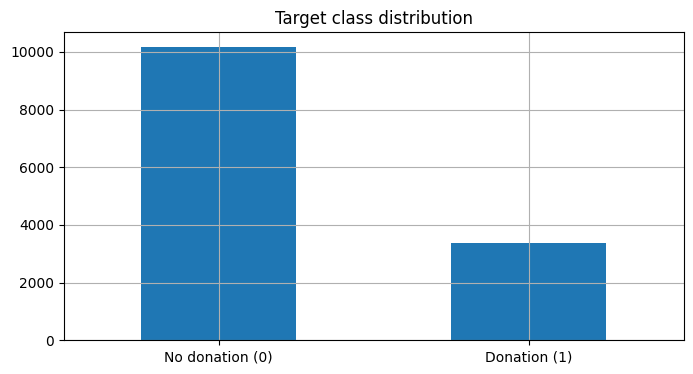

Positive response rate: 0.25


In [0]:
# Visualize the target distribution to assess imbalance.
# This is directly relevant for metric selection and threshold tuning.
class_counts = y_full.value_counts().sort_index()
ax = class_counts.plot(kind='bar')
ax.set_xticklabels(['No donation (0)', 'Donation (1)'], rotation=0)
ax.set_title('Target class distribution')
plt.show()

print('Positive response rate:', round(y_full.mean(), 4))


In [0]:
# Compute simple linear correlations between numerical predictors and the target.
# This is not used as a formal feature-selection rule; it is an exploratory signal.
eda_df = pd.concat([X_model_full[numeric_cols], y_full], axis=1)
correlations = (
    eda_df.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=np.abs, ascending=False)
)
correlations.head(12)


FREQUENCY_STATUS_97NK         0.125301
RECENT_CARD_RESPONSE_COUNT    0.121942
RECENT_RESPONSE_COUNT         0.120117
RECENT_RESPONSE_PROP          0.115570
PEP_STAR                      0.101275
RECENT_CARD_RESPONSE_PROP     0.097037
LIFETIME_GIFT_COUNT           0.096846
FILE_CARD_GIFT                0.094695
MONTHS_SINCE_LAST_GIFT       -0.086343
RECENT_AVG_GIFT_AMT          -0.076664
LIFETIME_CARD_PROM            0.064335
LAST_GIFT_AMT                -0.064212
Name: TARGET_B, dtype: float64

### Interpretation of the EDA findings

The exploratory analysis supports several practical conclusions that shape the rest of the notebook.

#### Mixed data structure
The dataset combines numerical and categorical information. This immediately justifies a `ColumnTransformer`-based preprocessing design, because different variable types require different treatment.

#### Non-negligible missingness
Since missing values are present, dropping incomplete observations would unnecessarily discard training information. This is particularly undesirable in a classification problem where the positive class is not dominant. Imputation is therefore preferable to row deletion.

#### Class imbalance
The positive class is materially less frequent than the negative class. This is one of the reasons why **accuracy** is not used as the primary optimization criterion. A classifier could achieve high accuracy by favoring the majority class, yet still perform poorly on donor detection.

#### Behavior-related variables are likely important
Variables related to historical donation frequency, donation amount, or recency tend to show stronger associations with the target. This is intuitively coherent: people with stronger prior engagement are more likely to donate again. Although correlation does not imply causality, these patterns justify giving special attention to behavioral variables in later interpretation.

Overall, the EDA suggests that a robust mixed-type preprocessing pipeline, imbalance-aware evaluation, and careful interpretation of donor history variables are all warranted.


## 5. Preprocessing design

This section defines the preprocessing strategy used by all models.

### Why use pipelines instead of manual preprocessing?

Pipelines are essential for methodological correctness because they ensure that every transformation is learned **only from the training data available within each fit**. This reduces the risk of leakage and makes the workflow reproducible.

### Numerical preprocessing choices

#### Median imputation
Median imputation is used for numerical variables because it is robust to skewness and extreme values. Donation-related variables often have asymmetric distributions, so the median is more defensible than the mean in this context.

#### Standardization for scale-sensitive models
A scaled numerical pipeline is used for Logistic Regression because linear models are sensitive to feature scale. Standardization helps optimization converge more reliably and prevents large-scale variables from dominating the coefficient estimation purely due to magnitude.

### Categorical preprocessing choices

#### Most-frequent imputation
For categorical variables, missing values are imputed with the most frequent category. This is a simple and defensible baseline when the project goal is prediction rather than causal inference. It preserves sample size and avoids introducing unsupported synthetic categories.

#### One-hot encoding with `handle_unknown='ignore'`
One-hot encoding is appropriate because the categorical attributes are nominal or ordinal-like codes stored as labels. The `handle_unknown='ignore'` option is crucial in a deployment setting: if a category appears in validation or test that was not observed during training, the pipeline will still run safely.

### Why maintain two preprocessors?

- **Scaled preprocessor**: used with Logistic Regression.
- **Unscaled preprocessor**: used with tree-based models.

Tree-based methods are generally insensitive to monotonic scaling, so standardization is unnecessary for them. Keeping separate preprocessors makes the workflow more efficient and conceptually cleaner.


In [0]:
# Numerical preprocessing for scale-sensitive models.
# Median imputation is robust to skewed donation-related distributions,
# and standardization improves optimization for linear classifiers.
numeric_pipe_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Numerical preprocessing for tree-based models.
# Trees are not sensitive to feature scale, so standardization is unnecessary.
numeric_pipe_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Categorical preprocessing shared by all models.
# The most frequent category is used as a simple baseline imputer,
# and one-hot encoding turns discrete labels into model-usable indicators.
categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Full preprocessor for linear models.
preprocessor_scaled = ColumnTransformer(transformers=[
    ('num', numeric_pipe_scaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])

# Full preprocessor for tree-based models.
preprocessor_tree = ColumnTransformer(transformers=[
    ('num', numeric_pipe_unscaled, numeric_cols),
    ('cat', categorical_pipe, categorical_cols)
])


## 6. Initial benchmark on the training partition

The purpose of this section is to compare several candidate algorithms under a common assessment protocol before moving to manual tuning.

### Why benchmark first?

A benchmark phase helps answer a fundamental question: which model families appear promising enough to justify deeper optimization? Rather than tuning everything exhaustively, we first screen a diverse set of candidate methods.

### Candidate models

The notebook evaluates four algorithms covered in class and implemented in scikit-learn:

1. **Logistic Regression** — a strong linear baseline that is interpretable and often competitive.
2. **Decision Tree** — a simple non-linear model that can capture threshold-like effects.
3. **Random Forest** — an ensemble method that usually improves stability and predictive strength relative to a single tree.
4. **Extra Trees** — a more randomized tree ensemble that may reduce variance and uncover alternative decision boundaries.

### Assessment protocol

The benchmark is run with **stratified 5-fold cross-validation on the training partition only**.

This is a deliberate choice:

- using only the training partition preserves the independence of validation and internal test;
- cross-validation gives a more stable estimate than a single split;
- stratification protects class proportions across folds.

### Metrics reported

- **F1**: primary metric, aligned with the Kaggle competition and suitable for imbalanced classes.
- **Precision**: important because false positives may imply unnecessary donor contact.
- **Recall**: important because missing likely donors also has an operational cost.
- **ROC AUC**: useful as a threshold-independent ranking measure.

The benchmark does not decide the final model by itself. Instead, it identifies the most promising candidates for more careful tuning.


In [0]:
# Define the cross-validation strategy for the initial benchmark.
# Only the training partition is used here, preserving validation and internal test.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = ['f1', 'precision', 'recall', 'roc_auc']

# Create a diverse benchmark set with four algorithms covered in class.
benchmark_models = {
    'Logistic Regression': Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE))
    ]),
    'Decision Tree': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', DecisionTreeClassifier(max_depth=6, min_samples_leaf=25, random_state=RANDOM_STATE))
    ]),
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            n_estimators=200,
            max_depth=8,
            min_samples_leaf=10,
            class_weight='balanced_subsample',
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ]),
    'Extra Trees': Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', ExtraTreesClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=5,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            n_jobs=1
        ))
    ])
}

# Evaluate each candidate with the same protocol and summarize the mean test-fold metrics.
benchmark_rows = []
for name, pipeline in benchmark_models.items():
    cv_results = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False
    )
    benchmark_rows.append({
        'model': name,
        'f1_mean': cv_results['test_f1'].mean(),
        'precision_mean': cv_results['test_precision'].mean(),
        'recall_mean': cv_results['test_recall'].mean(),
        'roc_auc_mean': cv_results['test_roc_auc'].mean()
    })

benchmark_df = pd.DataFrame(benchmark_rows).sort_values('f1_mean', ascending=False)
benchmark_df


,model,f1_mean,precision_mean,recall_mean,roc_auc_mean
0,Logistic Regression,0.400058,0.311607,0.558995,0.605857
2,Random Forest,0.380623,0.344419,0.426244,0.612059
3,Extra Trees,0.379567,0.335975,0.437070,0.612420
1,Decision Tree,0.119020,0.382459,0.071772,0.571225


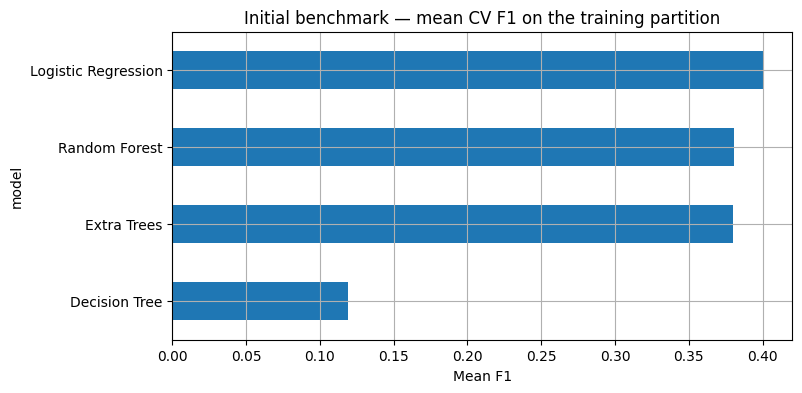

In [0]:
# Plot the benchmark results for an easier visual comparison of candidate models.
plot_df = benchmark_df.sort_values('f1_mean', ascending=True)
ax = plot_df.plot(x='model', y='f1_mean', kind='barh', legend=False)
ax.set_title('Initial benchmark — mean CV F1 on the training partition')
ax.set_xlabel('Mean F1')
plt.show()


### Why these candidates were selected for tuning

The benchmark stage provides a first ranking, but the final decision should not be made solely on average cross-validation scores. Instead, the benchmark is used as a **screening device**.

The two strongest and most complementary model families are carried forward:

- **Logistic Regression**, because it provides a transparent linear baseline and often performs strongly when the feature space is high-dimensional after one-hot encoding.
- **Random Forest**, because it can model non-linear interactions and heterogeneous predictor effects without requiring explicit interaction engineering.

This pairing is useful academically because it compares:

- a simpler, more interpretable linear model,
- against a flexible non-linear ensemble.

That contrast makes the final modeling discussion more substantive than comparing several extremely similar algorithms.


## 7. Hyperparameter tuning on the validation partition

This section performs transparent model optimization using the validation set.

### Why not use automated search utilities here?

Although `GridSearchCV` could be used, a manual and explicit tuning loop is pedagogically useful in this notebook because it makes every tested configuration visible. This improves explainability during the presentation and shows exactly how each tuning decision was reached.

### Why tune the classification threshold?

For probabilistic classifiers, the default threshold of 0.50 is not always optimal, especially in imbalanced settings and when the target metric is F1. By explicitly searching over thresholds, we align the final decision rule with the competition objective instead of assuming that the default threshold is automatically appropriate.

### Methodological separation

At this stage:

- the model is fitted on **train**,
- hyperparameters and thresholds are compared on **validation**,
- the internal test set remains untouched.

This separation is essential to maintain a credible final evaluation later.


In [0]:
# Evaluate a grid of probability thresholds.
# This function is central because the project is optimized for F1, and the default
# threshold of 0.50 is not guaranteed to be optimal in an imbalanced classification task.
def evaluate_thresholds(y_true, proba, grid=None):
    if grid is None:
        grid = np.round(np.arange(0.20, 0.81, 0.02), 2)

    rows = []
    for thr in grid:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': thr,
            'f1': f1_score(y_true, pred),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0)
        })

    return pd.DataFrame(rows).sort_values(['f1', 'precision', 'recall'], ascending=False).reset_index(drop=True)


# Fit a model on the training partition, score its probabilities on validation,
# and select the threshold that maximizes the validation F1 score.
def fit_score_threshold(model, X_train, y_train, X_valid, y_valid):
    model.fit(X_train, y_train)
    valid_proba = model.predict_proba(X_valid)[:, 1]
    threshold_df = evaluate_thresholds(y_valid, valid_proba)
    best_thr = float(threshold_df.iloc[0]['threshold'])
    return model, threshold_df, best_thr


In [0]:
# Transparent tuning loop for Logistic Regression.
# We vary the inverse regularization strength C and keep the search space intentionally
# compact so every tested configuration can be explained during the presentation.
lr_candidates = [0.05, 0.1, 0.3, 1, 3]
lr_results = []
lr_artifacts = {}

for C in lr_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=RANDOM_STATE, C=C))
    ])
    fitted_model, threshold_df, best_thr = fit_score_threshold(model, X_train, y_train, X_valid, y_valid)
    best_row = threshold_df.iloc[0].to_dict()
    lr_results.append({
        'C': C,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })
    lr_artifacts[C] = (fitted_model, threshold_df, best_thr)

lr_tuning_df = pd.DataFrame(lr_results).sort_values('val_f1', ascending=False)
lr_tuning_df


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bold-bug-594 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/7fa920c303ef4a5c8d5710f85c3c5cea
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run gifted-horse-363 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/48e1faf4130e41f2a2951bfa3717a75d
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run bright-snipe-184 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/d3348be182f547e791b529eb0ddad1a7
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687


,C,best_threshold,val_f1,val_precision,val_recall
2,0.30,0.44,0.416218,0.289247,0.741888
1,0.10,0.44,0.415907,0.289171,0.740413
0,0.05,0.44,0.415563,0.288838,0.740413
4,3.00,0.46,0.415350,0.299284,0.678466
3,1.00,0.44,0.415219,0.288506,0.740413


In [0]:
# Transparent tuning loop for Random Forest.
# The search space explores different trade-offs between ensemble size, depth,
# and leaf granularity, all of which affect bias-variance behavior.
rf_candidates = [
    {'n_estimators': 200, 'max_depth': 6, 'min_samples_leaf': 10},
    {'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 10},
    {'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 5},
    {'n_estimators': 300, 'max_depth': 12, 'min_samples_leaf': 5},
]

rf_results = []
rf_artifacts = {}

for cfg in rf_candidates:
    model = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **cfg
        ))
    ])
    fitted_model, threshold_df, best_thr = fit_score_threshold(model, X_train, y_train, X_valid, y_valid)
    best_row = threshold_df.iloc[0].to_dict()
    label = str(cfg)
    rf_results.append({
        'config': label,
        'best_threshold': best_thr,
        'val_f1': best_row['f1'],
        'val_precision': best_row['precision'],
        'val_recall': best_row['recall']
    })
    rf_artifacts[label] = (fitted_model, threshold_df, best_thr)

rf_tuning_df = pd.DataFrame(rf_results).sort_values('val_f1', ascending=False)
rf_tuning_df


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run classy-crow-940 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/adc3a8099dfc41e6accdcb4a17c0e99f
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

...

🏃 View run ambitious-quail-199 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/f12694cf460647bc9487bb6bf414f029
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run welcoming-bear-65 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/e9d5c6b1cd264fcabc1ef4117e27d20c
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687


,config,best_threshold,val_f1,val_precision,val_recall
2,"{'n_estimators': 300, 'max_depth': 8, 'min_sam...",0.44,0.418583,0.306951,0.657817
0,"{'n_estimators': 200, 'max_depth': 6, 'min_sam...",0.46,0.417375,0.306944,0.651917
1,"{'n_estimators': 200, 'max_depth': 8, 'min_sam...",0.40,0.417272,0.281588,0.805310
3,"{'n_estimators': 300, 'max_depth': 12, 'min_sa...",0.38,0.414517,0.294593,0.699115


## 8. Final comparison on the internal test partition

Once the best configuration from each candidate family has been selected on validation, the notebook performs a final comparison on the internal test partition.

### Why is this step necessary?

Validation performance is useful for model development, but it is still part of the tuning process. A model that looks best on validation may not remain best on genuinely untouched data. The internal test partition provides the fairest available estimate of out-of-sample behavior within the labeled training file.

### What is compared here?

For each tuned candidate model, we evaluate:

- F1 score,
- precision,
- recall,
- ROC AUC,
- and the tuned threshold that generated the binary predictions.

### Important methodological note

This internal test partition is intended for **final comparison only**. It should not be used to tune additional hyperparameters or to search for a better threshold afterward. Otherwise, it would stop being a true test set.


In [0]:
# Retrieve the best Logistic Regression configuration according to validation F1.
best_lr_C = lr_tuning_df.iloc[0]['C']
best_lr_model, best_lr_thresholds, best_lr_thr = lr_artifacts[best_lr_C]

# Retrieve the best Random Forest configuration according to validation F1.
best_rf_label = rf_tuning_df.iloc[0]['config']
best_rf_model, best_rf_thresholds, best_rf_thr = rf_artifacts[best_rf_label]

# Compare the strongest tuned representative from each candidate family
# on the untouched internal test partition.
candidate_models = {
    'Optimized Logistic Regression': (best_lr_model, best_lr_thr),
    'Optimized Random Forest': (best_rf_model, best_rf_thr)
}

final_eval_rows = []
for name, (estimator, thr) in candidate_models.items():
    probas = estimator.predict_proba(X_test_internal)[:, 1]
    preds = (probas >= thr).astype(int)
    final_eval_rows.append({
        'model': name,
        'threshold': thr,
        'f1_test': f1_score(y_test_internal, preds),
        'precision_test': precision_score(y_test_internal, preds, zero_division=0),
        'recall_test': recall_score(y_test_internal, preds, zero_division=0),
        'roc_auc_test': roc_auc_score(y_test_internal, probas)
    })

final_eval_df = pd.DataFrame(final_eval_rows).sort_values('f1_test', ascending=False)
final_eval_df


,model,threshold,f1_test,precision_test,recall_test,roc_auc_test
0,Optimized Logistic Regression,0.44,0.412170,0.284275,0.749263,0.589443
1,Optimized Random Forest,0.44,0.400739,0.291667,0.640118,0.589918


### Final model selection rationale

The model selected for deployment is the one that performs best on the internal test partition according to the project objective, with F1 treated as the primary criterion.

### Why prioritize F1?

F1 is the harmonic mean of precision and recall. It is especially appropriate here because:

- the positive class is not dominant,
- both false positives and false negatives matter,
- and Kaggle ranking for this project is based on binary F1.

### Why not optimize exclusively for ROC AUC?

ROC AUC is useful for evaluating ranking quality, but the final competition output is a hard class prediction, not just a probability ranking. Therefore, threshold-dependent performance matters directly, and F1 is the most operationally relevant criterion for selecting the final classification rule.


In [0]:
# Freeze the winning model family and its tuned configuration.
best_model_name = final_eval_df.iloc[0]['model']
print('Chosen final model:', best_model_name)

if best_model_name == 'Optimized Logistic Regression':
    final_threshold = best_lr_thr
    final_model = Pipeline(steps=[
        ('preprocessor', preprocessor_scaled),
        ('model', LogisticRegression(
            max_iter=3000,
            class_weight='balanced',
            random_state=RANDOM_STATE,
            C=best_lr_C
        ))
    ])
else:
    # Rebuild the final Random Forest using the best validation-selected configuration.
    best_cfg = eval(best_rf_label)
    final_threshold = best_rf_thr
    final_model = Pipeline(steps=[
        ('preprocessor', preprocessor_tree),
        ('model', RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,
            class_weight='balanced_subsample',
            **best_cfg
        ))
    ])

print('Frozen threshold from validation:', final_threshold)


Chosen final model: Optimized Logistic Regression
Frozen threshold from validation: 0.44


## 9. Refit on train + validation and final internal test assessment

After selecting the winning model family and configuration, the model is retrained on the union of **train + validation**.

### Why refit after model selection?

Once the best hyperparameters and decision threshold have been fixed, it is sensible to use as much labeled data as possible for the final fitted model. By combining train and validation, we give the selected algorithm more information from which to learn the final parameter estimates.

### Why keep the threshold frozen?

The threshold was chosen on the validation set. After that decision is made, it must remain fixed. Re-optimizing the threshold using the internal test set would leak information from the evaluation data back into the model-selection process.

### Why still report internal test performance after refit?

Although the internal test set was already used for final comparison, reporting confusion matrix and classification metrics for the chosen model remains useful for interpretation. These outputs help explain where the model succeeds and where errors remain.


In [0]:
# Refit the selected model on all data that was legitimately available for model development.
X_refit = pd.concat([X_train, X_valid], axis=0)
y_refit = pd.concat([y_train, y_valid], axis=0)

final_model.fit(X_refit, y_refit)

# Evaluate the refitted model on the internal test partition using the frozen threshold.
test_proba = final_model.predict_proba(X_test_internal)[:, 1]
test_pred = (test_proba >= final_threshold).astype(int)

print('Confusion matrix:', confusion_matrix(y_test_internal, test_pred))
print('Classification report:')
print(classification_report(y_test_internal, test_pred, digits=4))
print('ROC AUC:', round(roc_auc_score(y_test_internal, test_proba), 4))
print('F1     :', round(f1_score(y_test_internal, test_pred), 4))


Uploading artifacts:   0%|          | 0/3 [00:00<?, ?it/s]

Uploading artifacts:   0%|          | 0/9 [00:00<?, ?it/s]

🏃 View run learned-mule-671 at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687/runs/35923d52ff1d4641a00f27d08c55f3ea
🧪 View experiment at: https://dbc-701a66cb-661b.cloud.databricks.com/ml/experiments/1009253139793687
Confusion matrix: [[ 770 1264]
 [ 176  502]]
Classification report:
              precision    recall  f1-score   support

           0     0.8140    0.3786    0.5168      2034
           1     0.2843    0.7404    0.4108       678

    accuracy                         0.4690      2712
   macro avg     0.5491    0.5595    0.4638      2712
weighted avg     0.6815    0.4690    0.4903      2712

ROC AUC: 0.5931
F1     : 0.4108


## 10. Deployment — generating predictions for the Kaggle test file

This section translates the selected modeling strategy into the final project deliverable: a CSV file with predictions for the independent `donors_test.csv` dataset.

### Why is this a distinct section?

A good academic notebook should clearly separate **model development** from **deployment**. Up to this point, the notebook focused on selecting a reliable solution. Here, the objective changes: we now apply the frozen solution to previously unseen cases and generate the submission artifact required by the competition.

### What is preserved from earlier stages?

- the chosen model family,
- the chosen hyperparameters,
- the validation-selected threshold,
- and the rule that `CONTROL_NUMBER` is preserved only for identification in the output file.

This section is intentionally concise because deployment should be mechanically simple once the methodology has been decided correctly.


In [0]:
# Generate final predictions for the independent Kaggle test set.
final_test_proba = final_model.predict_proba(X_kaggle_model)[:, 1]
final_test_pred = (final_test_proba >= final_threshold).astype(int)

# Preserve the control number so that each prediction remains linked to the correct donor.
submission = pd.DataFrame({
    ID_COL: test_df[ID_COL],
    TARGET: final_test_pred
})

submission_path = 'DMNT_Group06_noebook_v5_documented.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
submission.head()


Submission saved to: DMNT_Group06_noebook_v5_documented.csv


,CONTROL_NUMBER,TARGET_B
0,122653,0
1,184239,1
2,5172,1
3,135377,1
4,62119,1


## 11. Open-ended section

The project requires an additional analytical component that goes beyond building a predictive pipeline. In this notebook, the open-ended section focuses on **model interpretation and error analysis**.

### Why this objective is appropriate

Predictive performance alone is not enough for a convincing academic presentation. Stakeholders also want to know:

- which features appear most influential,
- what kinds of donors are harder to classify,
- and what the model's mistakes suggest about the limits of the available data.

### Chosen analyses

1. **Permutation importance** on the internal test partition to identify features that most affect predictive performance.
2. **Error-type analysis** to separate true positives, true negatives, false positives, and false negatives.
3. **Behavioral profile comparison** across error categories to understand where the model confuses donor types.

### Why these analyses add value

These tasks are relevant, interpretable, and defensible in a presentation. They connect the predictive pipeline to substantive donor behavior rather than stopping at a leaderboard-oriented perspective.


In [0]:
# Permutation importance is computed on the internal test partition.
# This method is model-agnostic and quantifies how much predictive performance drops
# when each variable is randomly shuffled.
perm = permutation_importance(
    final_model,
    X_test_internal,
    y_test_internal,
    n_repeats=5,
    random_state=RANDOM_STATE,
    scoring='f1',
    n_jobs=1
)

importance_df = pd.DataFrame({
    'feature': X_test_internal.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

importance_df.head(12)


In [0]:
# Plot the most influential variables for a concise presentation-oriented summary.
plot_imp = importance_df.head(12).sort_values('importance_mean', ascending=True)
ax = plot_imp.plot(x='feature', y='importance_mean', kind='barh', legend=False)
ax.set_title('Top 12 features by permutation importance (internal test)')
ax.set_xlabel('Average F1 decrease after permutation')
plt.show()


In [0]:
# Build an error-analysis table combining predictors, probabilities, and predicted classes.
error_analysis = X_test_internal.copy()
error_analysis['y_true'] = y_test_internal.values
error_analysis['proba'] = test_proba
error_analysis['y_pred'] = test_pred

# Classify each observation by prediction outcome.
error_analysis['error_type'] = np.select(
    [
        (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 1),
        (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 0),
        (error_analysis['y_true'] == 0) & (error_analysis['y_pred'] == 1),
        (error_analysis['y_true'] == 1) & (error_analysis['y_pred'] == 0),
    ],
    [
        'True Positive',
        'True Negative',
        'False Positive',
        'False Negative'
    ],
    default='Other'
)

error_analysis['error_type'].value_counts()


In [0]:
# Compare average behavioral variables across error types.
# This helps identify whether specific donor profiles are associated with systematic mistakes.
behavior_cols = [
    'RECENT_AVG_GIFT_AMT',
    'RECENT_RESPONSE_PROP',
    'LIFETIME_GIFT_AMOUNT',
    'MONTHS_SINCE_LAST_GIFT',
    'MONTHS_SINCE_FIRST_GIFT'
]

error_analysis.groupby('error_type')[behavior_cols].mean().round(2)


### Interpretation of the open-ended analysis

The interpretation layer is as important as the computation itself.

#### Feature importance
If historical giving and response variables dominate permutation importance, that is consistent with the intuition that donation behavior is persistent: donors who have engaged recently, more frequently, or with higher amounts tend to remain more likely to respond.

#### Error analysis
The confusion-matrix decomposition helps move beyond a single metric. In particular:

- **False positives** represent people predicted as donors who did not donate.
- **False negatives** represent missed opportunities, that is, people who would have donated but were not identified by the model.

Because F1 balances precision and recall, both error types matter. Examining their profiles helps explain whether the model fails mainly on borderline donors, infrequent donors, or donors with contradictory historical signals.

#### Academic value of this section
This open-ended analysis strengthens the project because it connects predictive performance to substantive interpretation. It shows not only that a model was fitted, but also that the results were interrogated critically.


## 12. Final conclusions

This notebook delivers a complete and academically defensible solution to the donor-response prediction problem.

### Main methodological strengths

- A clear **train / validation / internal test** protocol was used to reduce data leakage risk.
- Preprocessing was implemented with **pipelines and column transformers**, ensuring that imputation and encoding are learned only from training data within each fit.
- The benchmark covered **four scikit-learn models** discussed in class.
- The optimization stage considered not only hyperparameters but also the **classification threshold**, which is crucial for maximizing F1 in an imbalanced setting.
- The final deployment step produced a submission file directly from the selected and documented pipeline.

### Substantive takeaways

The most informative variables tend to be related to prior donor behavior, including donation recency, response proportion, and historical donation amounts. This pattern is intuitively plausible and suggests that donor engagement history contains strong predictive signal.

### Limitations

- Internal performance still depends on a finite split of the available labeled data.
- Threshold tuning is metric-specific, so the final decision rule is optimized for F1 rather than for other operational criteria.
- Some donor behavior may remain difficult to model because the available data does not fully capture campaign context or individual intent.

### Final statement

Overall, the final workflow is aligned with the project requirements, methodologically more rigorous than the earlier version, and documented in a way that supports both notebook grading and oral presentation.
